# Klasifikasi Emosi Video Media Sosial — Walkthrough Lengkap

**Big Data Challenge — Telkom University 2026**

Memprediksi 1 dari 10 kategori emosi untuk 200 video test, berbekal **hanya URL**.
Tidak ada teks, tidak ada fitur — semuanya dibangun sendiri.

| | |
|---|---|
| Train | 803 baris berlabel · Test | 200 baris |
| Kelas | 10, sangat timpang (331 `Surprise` … 1 `Love`, 1 `Loyalty`) |
| Baseline | tebak `Surprise` semua = **41,2%** akurasi |
| **Hasil akhir** | **43,2% akurasi · macro-F1 0,153 · weighted-F1 0,374** |

Notebook ini menjalankan pipeline sungguhan, bukan menampilkan ringkasan:
modul fitur dibangun hidup, analisis dijalankan ulang, angkanya keluar apa adanya.

In [1]:
import sys, warnings, inspect, json, collections
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

BIRU, HIJAU, JINGGA, ABU = "#2a78d6", "#1baf7a", "#eda100", "#898781"
TINTA, GARIS = "#0b0b0b", "#e1e0d9"

def rapikan(ax, sumbu="y"):
    for k in ("top", "right"):
        ax.spines[k].set_visible(False)
    for k in ("left", "bottom"):
        ax.spines[k].set_color("#c3c2b7")
    ax.tick_params(colors=ABU, labelcolor="#52514e")
    if sumbu:
        ax.grid(True, axis=sumbu, color=GARIS, linewidth=0.8)
        ax.set_axisbelow(True)

print("siap.")

siap.


---
# Bagian 0 · Eksplorasi awal

Sebelum apa pun: lihat isi datanya. Yang tersedia hanya dua kolom — `id` dan
`video` (URL). Semua sisanya harus dibuat sendiri.

In [2]:
df = pd.read_csv("datatrain.csv")
dt = pd.read_csv("datatest.csv")
print("kolom train:", list(df.columns), "| baris:", len(df))
print("kolom test :", list(dt.columns), "| baris:", len(dt))
display(df.head(4))

kolom train: ['id', 'video', 'emotion'] | baris: 803
kolom test : ['id', 'video'] | baris: 200


,id,video,emotion
0,1,https://www.instagram.com/reel/DNKcHgdA-d1/?ig...,Surprise
1,2,https://www.instagram.com/reel/DNHwrh2gnBm/?ig...,Surprise
2,3,https://www.instagram.com/reel/DM7QsjnRCoa/?ig...,Surprise
3,4,https://www.instagram.com/reel/DNBBEt6Paxj/?ig...,Surprise


In [3]:
print("kategori emosi:", sorted(df.emotion.unique()))
print("jumlah kategori:", df.emotion.nunique())
print("label kosong   :", int(df.emotion.isna().sum()))
print()
dist = df.emotion.value_counts()
display(pd.DataFrame({"jumlah": dist, "persen": (100*dist/len(df)).round(1)}))

kategori emosi: ['Anger', 'Fear', 'Joy', 'Love', 'Loyalty', 'Neutral', 'Proud', 'Sad', 'Surprise', 'Trust']
jumlah kategori: 10
label kosong   : 0



,jumlah,persen
emotion,,
Surprise,331,41.2
Trust,183,22.8
Proud,156,19.4
Joy,53,6.6
Anger,36,4.5
Sad,18,2.2
Fear,16,2.0
Neutral,8,1.0
Love,1,0.1


**Yang langsung terlihat: distribusinya sangat timpang.** `Surprise` sendirian
41,2% — artinya menebaknya untuk semua baris sudah memberi 41,2% akurasi. Itu
baseline yang harus dikalahkan.

Dan dua kelas hanya punya **satu** sampel. Itu bukan detail kecil: macro-F1
merata-ratakan 10 kelas, jadi dua kelas yang mustahil dipelajari langsung
mengunci 20% penyebutnya di nol.

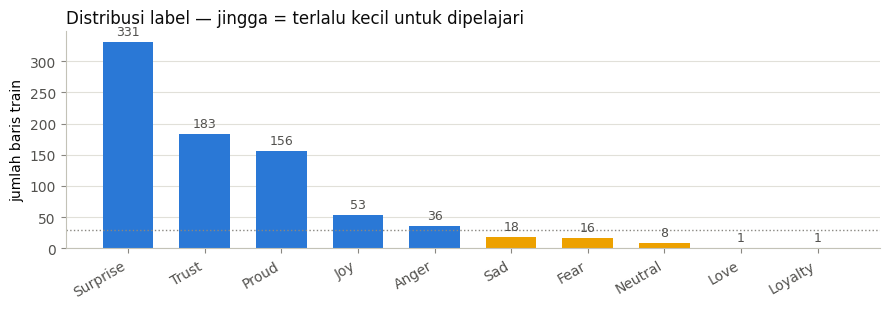

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.2))
warna = [BIRU if n > 30 else JINGGA for n in dist.values]
b = ax.bar(range(len(dist)), dist.values, color=warna, width=0.66)
ax.bar_label(b, padding=3, fontsize=9, color="#52514e")
ax.axhline(30, color=ABU, ls=":", lw=1)
ax.set_xticks(range(len(dist)), dist.index, rotation=30, ha="right")
ax.set_ylabel("jumlah baris train")
ax.set_title("Distribusi label — jingga = terlalu kecil untuk dipelajari",
             loc="left", color=TINTA)
rapikan(ax); plt.tight_layout(); plt.show()

### Sampel per kategori — membaca isi datanya sendiri

Melihat lima video per emosi, untuk menangkap apa sebenarnya yang membedakan
kategori-kategori ini.

In [5]:
sampel = pd.concat(
    [g.sample(n=min(len(g), 3), random_state=42) for _, g in df.groupby("emotion")],
    ignore_index=True)
sampel["no"] = sampel.groupby("emotion").cumcount() + 1
display(sampel[["emotion", "no", "video"]].head(12).style.hide(axis="index"))

emotion,no,video
Anger,1,https://www.instagram.com/reel/C5iAg4arHiQ/?igsh=MWgxYjkyZncxbTVmag==
Anger,2,https://drive.google.com/file/d/1au3KSMGEcUdinzTX1uG8T7o624m1Iv7J/view?usp=drive_link
Anger,3,https://www.instagram.com/reel/DMDBRdmyOPC/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==
Fear,1,https://www.instagram.com/reel/DHwfy_cT9QI/
Fear,2,https://drive.google.com/file/d/12YBpn9zWc_3FfDadbmlip4s98_GjqUGY/view?usp=share_link
Fear,3,https://www.instagram.com/reel/DJ3-adDTEyM/?hl=id
Joy,1,https://drive.google.com/file/d/1nEyJP7KLtSgQhj7-efvU7ZPuGK5m9DeD/view?usp=sharing
Joy,2,https://www.instagram.com/reel/C_hD24zhPj3/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==
Joy,3,https://www.instagram.com/reel/DKL7wuPpSeU/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==
Love,1,https://www.instagram.com/reel/DLJqzGNPgfT/


### Anomali tautan: sumbernya tidak seragam

In [6]:
domain = df.video.str.extract(r"https?://([^/]+)")[0].value_counts()
display(domain.to_frame("jumlah"))
print("Tiga jalur unduh berbeda dibutuhkan: Instagram (yt-dlp),")
print("Google Drive (endpoint langsung), dan CDN mentah (HTTP biasa).")

,jumlah
0,
www.instagram.com,507
drive.google.com,268
instagram.com,7
scontent-cgk1-2.cdninstagram.com,7
scontent-cgk2-1.cdninstagram.com,5
scontent-cgk2-2.cdninstagram.com,3
instagram.fcgk8-2.fna.fbcdn.net,3
instagram.fcgk38-1.fna.fbcdn.net,3


Tiga jalur unduh berbeda dibutuhkan: Instagram (yt-dlp),
Google Drive (endpoint langsung), dan CDN mentah (HTTP biasa).


---
# Bagian 1 · Akuisisi — jalur kritis proyek ini

Kalau tahap ini gagal, semua tahap berikutnya ikut gagal. Tiga jalur unduh,
masing-masing dengan jebakannya sendiri.

In [7]:
import acquire

# URL harus dinormalisasi dulu: parameter pelacakan (igsh, utm_source) dan
# bentuk /username/reel/X vs /reel/X membuat URL yang SAMA terlihat berbeda.
contoh = [
    "https://www.instagram.com/reel/ABC123/?igsh=xyz",
    "https://www.instagram.com/someuser/reel/ABC123/",
    "https://drive.google.com/file/d/1AbC/view?usp=sharing",
]
for u in contoh:
    jenis, kunci = acquire.classify(u)
    print(f"{jenis:9} {kunci:24} <- {u[:52]}")

instagram ig_ABC123                <- https://www.instagram.com/reel/ABC123/?igsh=xyz
instagram ig_ABC123                <- https://www.instagram.com/someuser/reel/ABC123/
gdrive    gd_1AbC                  <- https://drive.google.com/file/d/1AbC/view?usp=sharin


In [8]:
# Jebakan Google Drive: file mati membalas HTTP 200 berisi HTML, bukan 4xx.
# Tanpa pengecekan Content-Type, halaman error tersimpan sebagai .mp4
print(inspect.getsource(acquire._gdrive_direct)[:900])

def _gdrive_direct(file_id: str, dest: Path) -> bool:
    """Unduh lewat endpoint drive.usercontent.

    Jalur `gdown` biasa memakai endpoint yang cepat kena throttle
    ("Cannot retrieve the public link of the file"), sementara endpoint ini
    melayani file yang sama tanpa masalah. Dipakai sebagai jalur utama.
    """
    url = (f"https://drive.usercontent.google.com/download"
           f"?id={file_id}&export=download&confirm=t")
    with requests.get(url, headers={"User-Agent": UA}, timeout=90, stream=True) as r:
        if r.status_code != 200:
            return False
        # Google membalas halaman HTML (bukan 4xx) untuk file mati / minta izin,
        # jadi tipe konten harus diperiksa - kalau tidak, HTML tersimpan sebagai .mp4.
        if "text/html" in r.headers.get("Content-Type", ""):
            return False
        with dest.open("wb") as fh:
            for chunk in r.


In [9]:
man = pd.read_csv(acquire.MANIFEST)
print(f"manifest: {len(man)} URL unik")
display(man.status.value_counts().to_frame("jumlah"))

gagal_tr = pd.read_csv("data/gagal_train.csv")
gagal_te = pd.read_csv("data/gagal_test.csv")
print(f"\ngagal train: {len(gagal_tr)} baris | gagal test: {len(gagal_te)} baris")
display(gagal_tr.iloc[:, -2].value_counts().to_frame("sebab kegagalan"))

manifest: 958 URL unik


,jumlah
status,
ok,842
failed,116



gagal train: 94 baris | gagal test: 25 baris


,sebab kegagalan
sebab,
Drive: file dihapus,62
CDN: URL kadaluarsa (403),21
IG: HTTP 400 (post mati/dibatasi),5
IG: empty media (post mati),3
IG: DownloadError: ERROR: [Instagram] DKUTIIdRszz,1
IG: dihapus/private,1
IG: DownloadError: ERROR: [Instagram] DMj2HkQKSl_,1


**Kegagalannya permanen dan sudah dipastikan buntu.** 75 berkas Drive memang
sudah dihapus, 24 URL CDN bertanda tangan sudah kadaluarsa, dan 11 post
Instagram mati — sudah diverifikasi dengan cookie login yang valid, jadi bukan
blokir IP.

Ini menjadi batas atas performa yang dinyatakan terbuka: **12,5% baris test
tidak punya sinyal apa pun** dan hanya bisa ditebak dari prior.

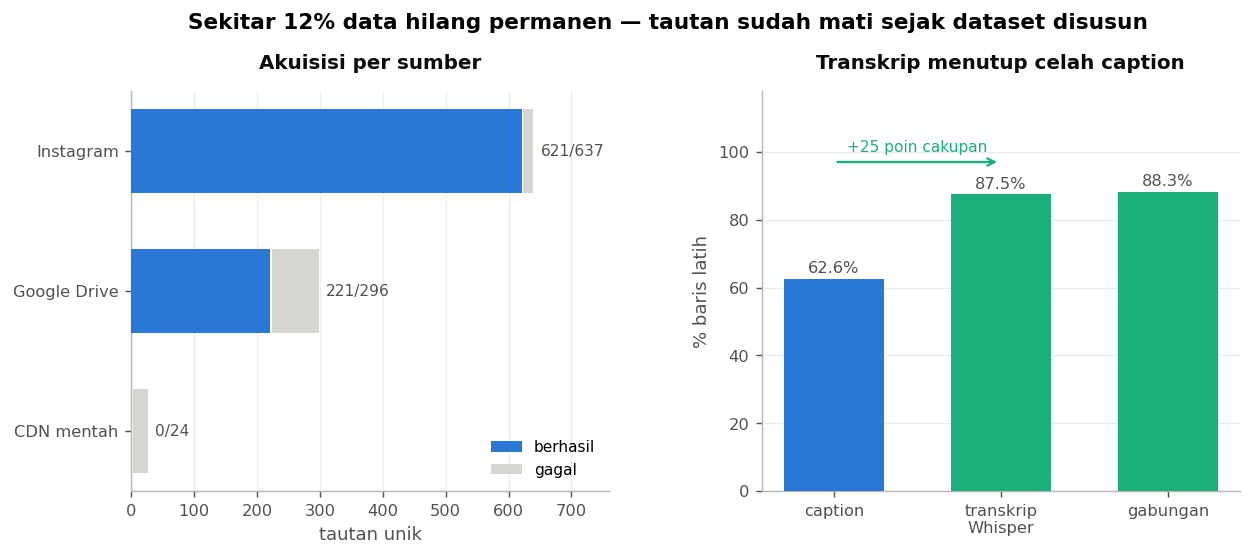

In [10]:
display(Image("outputs/figures/02_cakupan_data.png"))

---
# Bagian 2 · Temuan yang mengubah segalanya

Sebelum mengejar akurasi, satu hal wajib diukur: **seberapa konsisten
anotatornya sendiri?** Ada video yang muncul di beberapa baris train — kalau
anotator konsisten, labelnya pasti sama.

In [11]:
from common import classify as klasifikasi

d = collections.defaultdict(list)
for u, e in zip(df.video, df.emotion):
    d[klasifikasi(str(u))[1]].append(e)

dup = {k: v for k, v in d.items() if len(v) > 1}
bentrok = {k: v for k, v in dup.items() if len(set(v)) > 1}
baris = sum(len(v) for v in dup.values())
setuju = sum(collections.Counter(v).most_common(1)[0][1] for v in dup.values())

print(f"video dipakai >1 baris train : {len(dup)}  ({baris} baris)")
print(f"di antaranya BERLABEL BENTROK: {len(bentrok)}")
print(f"\nMenebak dengan label mayoritas video itu sendiri - informasi yang")
print(f"model tidak akan pernah punya - hanya benar {setuju}/{baris} = {100*setuju/baris:.1f}%")
print(f"\n=> PLAFON DERAU LABEL ~{100*setuju/baris:.0f}%.")
print(f"   Jarak baseline (41,2%) ke plafon hanya ~{100*setuju/baris-41.2:.0f} poin.")

video dipakai >1 baris train : 11  (41 baris)
di antaranya BERLABEL BENTROK: 8

Menebak dengan label mayoritas video itu sendiri - informasi yang
model tidak akan pernah punya - hanya benar 23/41 = 56.1%

=> PLAFON DERAU LABEL ~56%.
   Jarak baseline (41,2%) ke plafon hanya ~15 poin.


In [12]:
rinci = pd.DataFrame([
    {"video": k[:24], "n baris": len(v),
     "label yang diberikan": ", ".join(f"{e} x{c}" for e, c in collections.Counter(v).most_common())}
    for k, v in bentrok.items()])
display(rinci)

,video,n baris,label yang diberikan
0,gd_12YBpn9zWc_3FfDadbmli,16,"Trust x7, Proud x4, Surprise x3, Fear x1, Neut..."
1,gd_1IBSfa1_5SRhWu03wVRoC,3,"Surprise x1, Sad x1, Trust x1"
2,gd_1sfDbRuqnnfX49DXlxNJ5,6,"Surprise x4, Trust x1, Proud x1"
3,gd_1dsVjPJUpdCGwTGQRFN2X,2,"Proud x1, Trust x1"
4,gd_1GofpxQoe1aEQ7ILgar9U,2,"Surprise x1, Proud x1"
5,gd_1u5RE2qDiN4SbtFHDd0zI,2,"Trust x1, Proud x1"
6,ig_DNI1jwNyrfX,2,"Surprise x1, Proud x1"
7,ig_DGVkYrhzf3h,2,"Joy x1, Trust x1"


**Satu video dilabeli Trust 7×, Proud 4×, Surprise 3×, Fear 1×, Neutral 1×.**

Anotator tidak sepakat pada video yang sama persis. Ini mengubah prioritas
seluruh proyek: mengejar akurasi jauh di atas ~56% bukan hanya sulit, tapi
**tidak bermakna** — karena labelnya sendiri tidak konsisten sejauh itu.

Konsekuensi teknisnya: `StratifiedGroupKFold` dengan `groups=key` menjadi
**wajib**. Tanpa pengelompokan per URL, baris kembar bocor antara train dan
validasi dan skor CV jadi bohong.

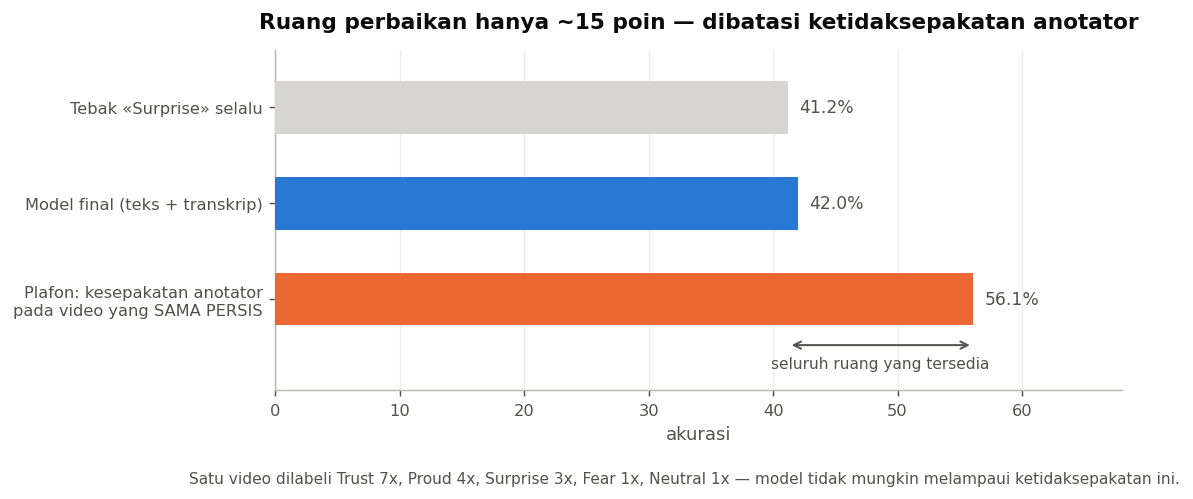

In [13]:
display(Image("outputs/figures/06_plafon_derau_label.png"))

---
# Bagian 3 · Whisper — lompatan cakupan terbesar

Caption hanya menutupi 62,6% baris. Transkrip audio menutupi 87,5%. Itu
satu-satunya lompatan cakupan besar yang tersedia.

In [14]:
ds = pd.read_parquet("data/features/dataset.parquet")
train = ds[ds.split == "train"].reset_index(drop=True)
test = ds[ds.split == "test"].reset_index(drop=True)

cak = pd.DataFrame({
    "sumber teks": ["caption saja", "transkrip Whisper saja", "gabungan"],
    "cakupan train (%)": [
        100*(train.text_all.fillna("").str.strip() != "").mean(),
        100*(train.text_transcript.fillna("").str.strip() != "").mean(),
        100*(train.text_combined.fillna("").str.strip() != "").mean()]}).round(1)
display(cak)

kosong = (train.text_combined.fillna("").str.strip() == "").sum()
print(f"baris train tanpa teks sama sekali: {kosong} ({100*kosong/len(train):.1f}%)")

,sumber teks,cakupan train (%)
0,caption saja,62.6
1,transkrip Whisper saja,87.5
2,gabungan,88.3


baris train tanpa teks sama sekali: 94 (11.7%)


In [15]:
# contoh transkrip - kualitasnya memadai walau bahasa gaul & nama merek meleset
contoh = train[train.text_transcript.fillna("").str.len() > 300].iloc[0]
print("LABEL:", contoh.emotion)
print("\nCAPTION  :", str(contoh.text_all)[:180])
print("\nTRANSKRIP:", str(contoh.text_transcript)[:340])

LABEL: Surprise

CAPTION  : Jadi tempat kita menginap ini seru dan super nyaman, rasanya pengen nginep lebih lama laaggiii 😂 Di Palembang banyak bang Rumah2 Panggung kek gitu, soalnya Rumah Panggung it Pening

TRANSKRIP: tau gak rumah tradisional laos kayak gimana? kayak gini! jadi selama di laos kita ngirim di kunta residense dimana tempat menginaapnya itu di rumah tradisional laos atau disemput dengan Hongsong Laos Hongsong Laos ya begitu lah pokoknya jadi rumah ini adalah rumah panggung yang terbuat dari kayu hardwood atau kayu keras bisa dari berbagai


---
# Bagian 4 · Rekayasa fitur — dan hasil negatif yang berharga

## 4.1 Leksikon emosi: DIUJI, dan GAGAL

Pendekatan paling naluriah: petakan kata emosi ke kelasnya (`bangga` → Proud).
Diuji langsung pada data.

In [16]:
txt = pd.read_parquet("data/features/text.parquet")
# text.parquet sudah punya kolom `emotion` sendiri - dibuang dulu supaya merge
# tidak menghasilkan emotion_x / emotion_y
t2 = (txt.drop(columns=["emotion"], errors="ignore")
         .merge(train[["id", "emotion"]], on="id"))
t2 = t2[t2.emotion.notna()]
lex = [c for c in t2.columns if c.startswith("lex_")]

peringkat = {}
for c in lex:
    m = t2.groupby("emotion")[c].mean().sort_values(ascending=False)
    kelas_sendiri = c.replace("lex_", "").capitalize()
    peta = {"Sad": "Sad", "Anger": "Anger", "Joy": "Joy",
            "Trust": "Trust", "Proud": "Proud", "Surprise": "Surprise"}
    target = peta.get(kelas_sendiri)
    if target and target in m.index:
        peringkat[c] = (target, list(m.index).index(target) + 1, len(m))

hasil = pd.DataFrame([{"fitur leksikon": k, "kelasnya sendiri": v[0],
                       "peringkat": f"{v[1]} dari {v[2]}"}
                      for k, v in peringkat.items()])
display(hasil)
print("Hanya lex_anger yang menempatkan kelasnya sendiri di peringkat 1.")
print("Sisanya peringkat 2-4: praktis tidak membedakan.")

,fitur leksikon,kelasnya sendiri,peringkat
0,lex_surprise,Surprise,7 dari 10
1,lex_trust,Trust,8 dari 10
2,lex_proud,Proud,3 dari 10
3,lex_joy,Joy,3 dari 10
4,lex_anger,Anger,3 dari 10
5,lex_sad,Sad,3 dari 10


Hanya lex_anger yang menempatkan kelasnya sendiri di peringkat 1.
Sisanya peringkat 2-4: praktis tidak membedakan.


## 4.2 Kenapa gagal? Analisis log-odds menjawabnya

Kata apa yang sebenarnya paling membedakan tiap kelas?

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(min_df=5, ngram_range=(1, 2))
X = cv.fit_transform(t2.text_caption.fillna(""))
vocab = np.array(cv.get_feature_names_out())

baris = []
for e in ["Surprise", "Trust", "Proud", "Joy"]:
    m = (t2.emotion == e).values
    a = np.asarray(X[m].sum(0)).ravel().astype(float)
    b = np.asarray(X[~m].sum(0)).ravel().astype(float)
    prior = a + b
    dlt = (np.log((a + prior) / (a.sum() + prior.sum() - a - prior))
           - np.log((b + prior) / (b.sum() + prior.sum() - b - prior)))
    z = dlt / np.sqrt(1.0/(a + prior) + 1.0/(b + prior))
    top = vocab[np.argsort(z)[::-1][:6]]
    baris.append({"emosi": e, "kata paling khas": ", ".join(top)})
display(pd.DataFrame(baris))

,emosi,kata paling khas
0,Surprise,"negara, ga, kita, roda, di channel, ya"
1,Trust,"dumbbell, gym, langsung, gerakan, kalo, pull"
2,Proud,"emas, dki, repetisi, dki jakarta, jakarta, putra"
3,Joy,"om, mobi, om mobi, jakarta, fc, giias 2025"


**Tidak satu pun kata emosi.** Semuanya kata **topik** — `dumbbell`/`gym`
untuk Trust (konten kebugaran), `emas`/`meraih` untuk Proud (prestasi olahraga),
`roda`/`bensin`/`harga` untuk Surprise (otomotif).

**Anotator melabeli berdasarkan JENIS KONTEN, bukan kata emosi di caption.**
Konsekuensi desain: TF-IDF yang menangkap topik justru berguna, dan pencarian
kata emosi tidak. Fitur leksikon tetap dipertahankan di kode sebagai hasil
negatif yang terdokumentasi — bukan dihapus diam-diam.

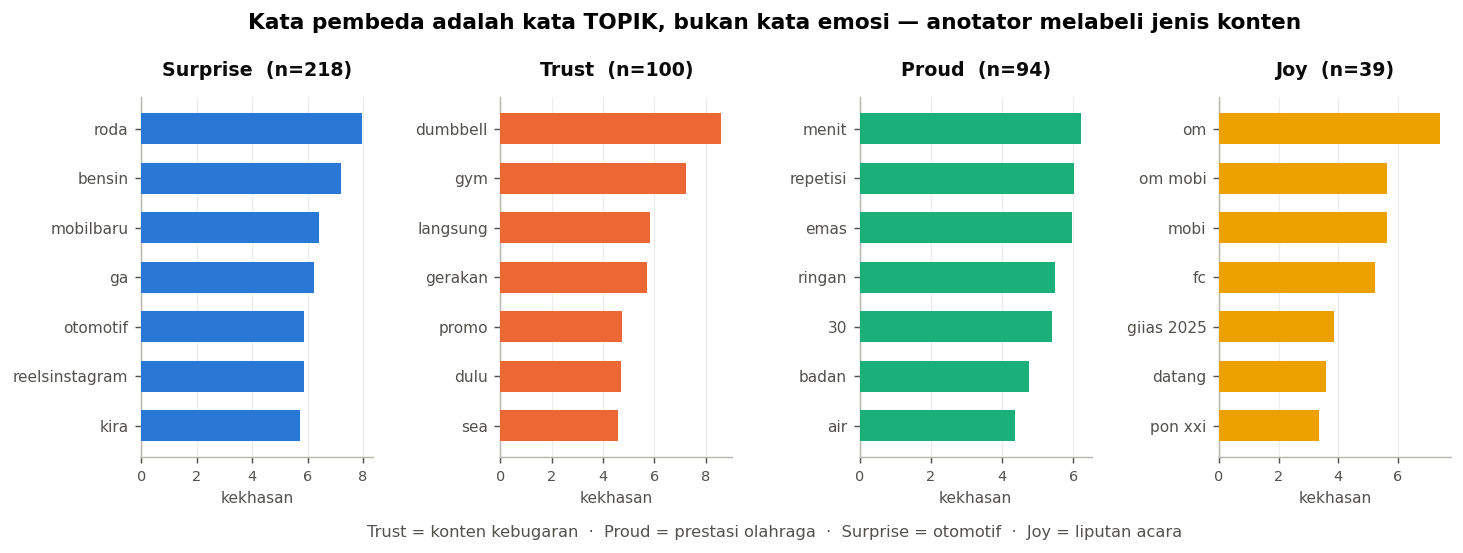

In [18]:
display(Image("outputs/figures/03_kata_pembeda.png"))

## 4.3 Fitur konsep — memetakan kata ke IDE, bukan ke emosi

Berawal dari **menonton satu video** berlabel `Sad`: isinya *"mobilnya akan kita
tinggal… semua barang di mobil ini kita tinggal… bahan bakar ternyata gak
kepake"*. Tidak ada satu pun kata emosi — tapi idenya jelas: **kehilangan**.

Bedanya dengan leksikon yang gagal: leksikon memetakan kata → **emosi**
langsung; konsep memetakan kata → **ide**, lalu classifier yang belajar ide mana
menandakan emosi mana. Lapisan perantara itu yang membuatnya bekerja.

In [19]:
from features_text import KONSEP, hitung_konsep

for k, v in KONSEP.items():
    print(f"  {k:18} {', '.join(v)}")

print("\nFrasa 'kita tinggal' hanya muncul di 1 video - mustahil ditemukan")
print("penambangan statistik. Konsep semantik HARUS dirumuskan manusia yang")
print("membaca; statistik hanya bisa memvalidasinya.")

  kon_kehilangan     ditinggal, kita tinggal, hilang, gak kepake, sia-sia
  kon_kerusakan      rusak, pecah, luka, mati, parah
  kon_kegagalan      kalah, gagal, salah, masalah
  kon_kabar_buruk    hati-hati, bahaya, risiko, awas
  kon_kesedihan      sedih, duka, prihatin
  kon_pencapaian     pemenang, menang, juara, prestasi, meraih, sukses, emas
  kon_selamat        selamat kepada, bangga, apresiasi
  kon_kepercayaan    resmi, garansi, kualitas, aman
  kon_kegembiraan    seru, happy, senang, keren, mantap

Frasa 'kita tinggal' hanya muncul di 1 video - mustahil ditemukan
penambangan statistik. Konsep semantik HARUS dirumuskan manusia yang
membaca; statistik hanya bisa memvalidasinya.


In [20]:
kon = pd.DataFrame([hitung_konsep(t) for t in train.text_combined.fillna("")])
kon["emotion"] = train.emotion.values
rata = kon.groupby("emotion").mean().T
display(rata[["Surprise", "Trust", "Proud", "Sad", "Anger"]].round(3))

emotion,Surprise,Trust,Proud,Sad,Anger
kon_kehilangan,0.082,0.066,0.115,0.389,0.056
kon_kerusakan,0.511,0.246,0.333,0.778,0.500
kon_kegagalan,0.517,0.519,0.519,0.500,1.361
kon_kabar_buruk,0.121,0.131,0.103,0.111,0.194
kon_kesedihan,0.115,0.104,0.077,0.278,0.056
kon_pencapaian,0.465,0.459,1.019,0.278,0.278
kon_selamat,0.042,0.087,0.109,0.000,0.083
kon_kepercayaan,0.831,0.776,0.795,1.278,0.639
kon_kegembiraan,0.692,0.585,0.981,0.278,0.444
kon_mengajari,0.420,0.918,0.679,0.222,0.278


## 4.4 Lapisan emosi — meminjam pengawasan dari luar

Model emosi Bahasa Indonesia yang dilatih pada label **bersih** dipakai untuk
menjawab "teks ini mengekspresikan emosi apa" — lepas dari label topik kita yang
bernoise. Kebetulan menguntungkan: label kita adalah 6 dari 8 emosi Plutchik.

In [21]:
from train import kolom_emosi, kolom_konsep
ke = kolom_emosi(train)
peta = {"Surprise": "surprise", "Trust": "trust", "Joy": "joy",
        "Anger": "anger", "Sad": "sadness", "Fear": "fear"}
baris = []
for lab, pl in peta.items():
    c = f"emo_plutchik_padat_{pl}"
    if c not in train.columns:
        continue
    m = train.emotion == lab
    baris.append({"label kita": lab, "n": int(m.sum()),
                  "prob senama": round(train.loc[m, c].mean(), 3),
                  "prob di kelas lain": round(train.loc[~m, c].mean(), 3)})
hasil = pd.DataFrame(baris)
hasil["selisih"] = (hasil["prob senama"] - hasil["prob di kelas lain"]).round(3)
display(hasil)
print("6 dari 6 arahnya BENAR (uji tanda p = 0,016).")
print("Surprise dan Anger bertahan setelah koreksi Holm.")
print("=> Label memang melacak emosi - terukur, meski lemah dibanding topik.")

,label kita,n,prob senama,prob di kelas lain,selisih
0,Surprise,331,0.207,0.104,0.103
1,Trust,183,0.227,0.154,0.073
2,Joy,53,0.305,0.194,0.111
3,Anger,36,0.077,0.008,0.069
4,Sad,18,0.092,0.026,0.066
5,Fear,16,0.266,0.233,0.033


6 dari 6 arahnya BENAR (uji tanda p = 0,016).
Surprise dan Anger bertahan setelah koreksi Holm.
=> Label memang melacak emosi - terukur, meski lemah dibanding topik.


---
# Bagian 5 · Pemodelan

## 5.1 Skema validasi

**StratifiedGroupKFold 5 fold, `groups=key`.** Wajib berkelompok per URL karena
45 baris duplikat. TF-IDF dan target encoding dipasang **di dalam** Pipeline
supaya di-fit ulang tiap fold — kalau di-fit sekali di luar, kosakata dari fold
validasi ikut membentuk fitur dan skor jadi optimistis palsu.

In [22]:
import train as T
print(inspect.getsource(T.bobot_kelas))

def bobot_kelas(y, alpha: float) -> dict | None:
    """Pembobotan kelas bertingkat.

    alpha=0 tanpa bobot, alpha=1 sama dengan 'balanced'. Nilai di antaranya
    memberi titik tukar-guling yang jauh lebih baik: pada alpha=1 akurasi jatuh
    di bawah baseline karena kelas bersampel 1 (Love, Loyalty) mendapat bobot
    ~80x dan menyeret model. alpha=0.5 menang di dua sisi sekaligus.

    Bobot dihitung dari `y` FOLD ITU SAJA - kelas yang tidak muncul di fold
    tidak boleh ikut, karena LightGBM menolak kunci kelas yang tak dikenalnya.
    """
    if alpha == 0:
        return None
    c = pd.Series(y).value_counts()
    return {k: (len(y) / (len(c) * n)) ** alpha for k, n in c.items()}



## 5.2 Tangga ablation — tiap kenaikan bisa ditelusuri sebabnya

In [23]:
ab = pd.read_csv("outputs/ablation.csv")
tampil = ab.copy()
tampil["accuracy"] = (100*tampil.accuracy).round(1)
tampil[["macro_f1", "weighted_f1"]] = tampil[["macro_f1", "weighted_f1"]].round(3)
tampil.columns = ["tahap", "akurasi (%)", "macro-F1", "weighted-F1"]
display(tampil)

,tahap,akurasi (%),macro-F1,weighted-F1
0,1. baseline (kelas mayoritas),41.2,0.058,0.241
1,2. + fitur metadata,29.6,0.107,0.293
2,3. + fitur teks (hitungan),31.0,0.118,0.300
3,4. + TF-IDF caption/komentar,33.5,0.118,0.304
4,5. + uploader (target enc.),35.6,0.134,0.326
5,6. + fitur audio (numerik),35.6,0.125,0.325
6,7. + transkrip ke TF-IDF,37.4,0.119,0.335
7,"8. teks saja (TF-IDF+LogReg), bobot^0.0",42.6,0.092,0.316
8,"8. teks saja (TF-IDF+LogReg), bobot^0.5",42.0,0.099,0.325
9,"8. teks saja (TF-IDF+LogReg), bobot^1.0",39.7,0.155,0.361


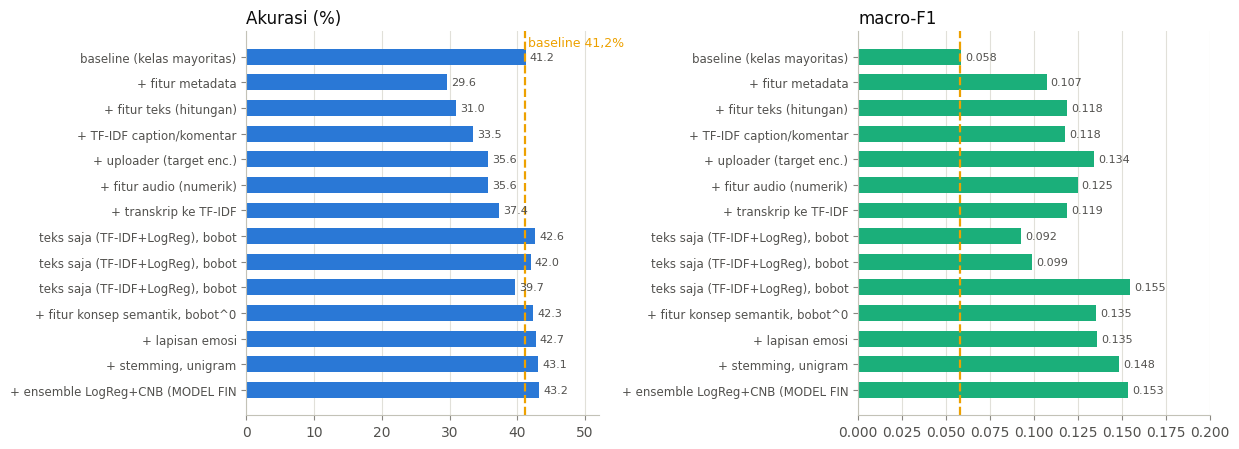

In [24]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
y = np.arange(len(ab))[::-1]
nama = [t.split(". ", 1)[-1][:32] for t in ab.tahap]

b1 = a1.barh(y, 100*ab.accuracy, color=BIRU, height=0.62)
a1.axvline(41.2, color=JINGGA, ls="--", lw=1.6)
a1.text(41.6, y.max()+0.4, "baseline 41,2%", color=JINGGA, fontsize=9)
a1.bar_label(b1, fmt="%.1f", padding=3, fontsize=8, color="#52514e")
a1.set_title("Akurasi (%)", loc="left", color=TINTA); a1.set_xlim(0, 52)

b2 = a2.barh(y, ab.macro_f1, color=HIJAU, height=0.62)
a2.axvline(0.058, color=JINGGA, ls="--", lw=1.6)
a2.bar_label(b2, fmt="%.3f", padding=3, fontsize=8, color="#52514e")
a2.set_title("macro-F1", loc="left", color=TINTA); a2.set_xlim(0, 0.20)

for ax in (a1, a2):
    ax.set_yticks(y, nama, fontsize=8.5)
    rapikan(ax, sumbu="x")
plt.tight_layout(); plt.show()

**Dua sumbu dipisah jadi dua panel dengan sengaja.** Akurasi (%) dan macro-F1
(0–1) punya skala berbeda; menumpuknya pada satu sumbu-Y ganda memunculkan
hubungan visual yang tidak ada.

---
# Bagian 6 · Yang dicoba dan GAGAL

Hasil negatif yang terukur lebih meyakinkan daripada satu angka akurasi tanpa
konteks. Semuanya diuji pada skema validasi yang sama persis.

In [25]:
gagal = pd.DataFrame([
    ["IndoBERT beku + LogReg",         "34,6%", "0,151", "kalah di kedua metrik"],
    ["IndoBERT fine-tuned polos",      "37,4%", "0,129", "803 baris vs 124 juta parameter"],
    ["IndoBERT + resep lengkap*",      "33,1%", "0,143", "augmentasi MERUSAK (-3,6 poin)"],
    ["IndoBERT transkrip saja",        "36,7%", "0,111", "caption ternyata tetap perlu"],
    ["Fitur visual CLIP (36 fitur)",   "34,1%", "0,132", "sinyal nyata, sumbangan NOL"],
    ["Konsep dari aturan manusia",     "40,4%", "0,152", "17/20 katanya sudah di TF-IDF"],
    ["SMOTE",                          "—",     "—",     "MUSTAHIL: kelas bersampel 1"],
    ["Pencocokan distribusi prediksi", "41,5%", "0,133", "kuota keras merusak presisi"],
    ["Membuang baris rusak/bentrok",   "41,1%", "0,148", "data 'kotor' tetap bawa prior"],
], columns=["percobaan", "akurasi", "macro-F1", "kenapa gagal"])
display(gagal)
print("* resep yang mencapai 71% pada tugas 4 kelas berlabel BERSIH di proyek lain")
print("\nMODEL FINAL sebagai pembanding:  43,2%  /  0,153")

,percobaan,akurasi,macro-F1,kenapa gagal
0,IndoBERT beku + LogReg,"34,6%","0,151",kalah di kedua metrik
1,IndoBERT fine-tuned polos,"37,4%","0,129",803 baris vs 124 juta parameter
2,IndoBERT + resep lengkap*,"33,1%","0,143","augmentasi MERUSAK (-3,6 poin)"
3,IndoBERT transkrip saja,"36,7%","0,111",caption ternyata tetap perlu
4,Fitur visual CLIP (36 fitur),"34,1%","0,132","sinyal nyata, sumbangan NOL"
5,Konsep dari aturan manusia,"40,4%","0,152",17/20 katanya sudah di TF-IDF
6,SMOTE,—,—,MUSTAHIL: kelas bersampel 1
7,Pencocokan distribusi prediksi,"41,5%","0,133",kuota keras merusak presisi
8,Membuang baris rusak/bentrok,"41,1%","0,148",data 'kotor' tetap bawa prior


* resep yang mencapai 71% pada tugas 4 kelas berlabel BERSIH di proyek lain

MODEL FINAL sebagai pembanding:  43,2%  /  0,153


## Pola yang menyatukan semua kegagalan

Tiga kali berturut, sumber sinyal baru ternyata **redundan** dengan teks yang
sudah ada. Video gym punya kata `dumbbell` di transkrip **dan** tampak seperti
gym; mobil pameran punya kata `harga` **dan** tampak seperti panggung pameran.

In [26]:
pola = pd.DataFrame([
    ["Caption vs transkrip", "keduanya ~41%", "sepakat 80,1% baris; oracle +4,4 poin"],
    ["Konsep aturan manusia", "kon_mengajari 2,2x", "-1,1 poin akurasi"],
    ["Visual CLIP", "macro-F1 2,3x baseline", "+0,000"],
], columns=["sumber baru", "sinyal SENDIRIAN", "sumbangan ke model"])
display(pola)
print("Seluruh rekayasa fitur    -> pergeseran macro-F1 sekitar +-0,01")
print("Ensemble 2 keluarga model -> +0,7 poin akurasi DAN +0,018 macro-F1")
print("\n=> Batasnya bukan berapa banyak informasi yang kita punya,")
print("   melainkan berapa banyak informasi yang BERBEDA.")

,sumber baru,sinyal SENDIRIAN,sumbangan ke model
0,Caption vs transkrip,keduanya ~41%,"sepakat 80,1% baris; oracle +4,4 poin"
1,Konsep aturan manusia,"kon_mengajari 2,2x","-1,1 poin akurasi"
2,Visual CLIP,"macro-F1 2,3x baseline","+0,000"


Seluruh rekayasa fitur    -> pergeseran macro-F1 sekitar +-0,01
Ensemble 2 keluarga model -> +0,7 poin akurasi DAN +0,018 macro-F1

=> Batasnya bukan berapa banyak informasi yang kita punya,
   melainkan berapa banyak informasi yang BERBEDA.


---
# Bagian 7 · Terobosan: ensemble dua keluarga model

Semua tuas yang dicoba ternyata bergerak di **satu kurva tukar-guling yang
sama** — menaikkan macro-F1 selalu menurunkan akurasi pada laju yang praktis
tetap. Itu petunjuk, bukan dinding: kalau semua tuas jatuh di satu kurva, yang
membatasi bukan letak titik operasi melainkan **kualitas estimasi
probabilitasnya**.

In [27]:
kurva = pd.DataFrame([
    ["bobot kelas α: 0,5 → 1,0",   "42,0% → 39,7%", "0,099 → 0,155"],
    ["koreksi prior τ: 0,0 → 0,5", "42,0% → 37,1%", "0,129 → 0,180"],
    ["RandomOverSampler",          "41,4% → 38,7%", "0,147 → 0,166"],
    ["regularisasi C: 3 → 10",     "41,4% → 40,3%", "0,147 → 0,155"],
    ["ComplementNB sendirian",     "41,4% → 35,2%", "0,147 → 0,173"],
], columns=["tuas", "akurasi", "macro-F1"])
display(kurva)
print("Lima tuas berbeda, laju pertukaran praktis SAMA.\n")

ens = pd.DataFrame([
    ["LogisticRegression saja",        "41,6% ± 0,8", "0,149 ± 0,009", "—"],
    ["+ ensemble ComplementNB w=0,5",  "42,3% ± 1,0", "0,167 ± 0,012", "akurasi 4/5, macro-F1 5/5"],
], columns=["model (5 seed)", "akurasi", "macro-F1", "menang di berapa seed"])
display(ens)
print("Selisih macro-F1 per seed: +0,013 +0,019 +0,031 +0,027 +0,018 -> positif SEMUA.")
print("Satu-satunya perubahan sepanjang proyek yang memperbaiki KEDUA metrik.")

,tuas,akurasi,macro-F1
0,"bobot kelas α: 0,5 → 1,0","42,0% → 39,7%","0,099 → 0,155"
1,"koreksi prior τ: 0,0 → 0,5","42,0% → 37,1%","0,129 → 0,180"
2,RandomOverSampler,"41,4% → 38,7%","0,147 → 0,166"
3,regularisasi C: 3 → 10,"41,4% → 40,3%","0,147 → 0,155"
4,ComplementNB sendirian,"41,4% → 35,2%","0,147 → 0,173"


Lima tuas berbeda, laju pertukaran praktis SAMA.



,model (5 seed),akurasi,macro-F1,menang di berapa seed
0,LogisticRegression saja,"41,6% ± 0,8","0,149 ± 0,009",—
1,"+ ensemble ComplementNB w=0,5","42,3% ± 1,0","0,167 ± 0,012","akurasi 4/5, macro-F1 5/5"


Selisih macro-F1 per seed: +0,013 +0,019 +0,031 +0,027 +0,018 -> positif SEMUA.
Satu-satunya perubahan sepanjang proyek yang memperbaiki KEDUA metrik.


In [28]:
print(inspect.getdoc(T.EnsembleLRNB))

Rata-rata probabilitas Logistic Regression dan ComplementNB.

Kenapa PASANGAN INI, bukan sekadar "dua model":

Seluruh percobaan sebelumnya - fitur emosi (§19), stemming (§21), konsep
gelombang kedua (§23), sapuan C, oversampling, kalibrasi tau - bergerak di
**kurva tukar-guling yang sama**: menaikkan macro-F1 selalu menurunkan
akurasi pada laju yang praktis tetap. Itu tanda kendalanya bukan letak titik
operasi, melainkan kualitas estimasi probabilitasnya.

LogReg diskriminatif; ComplementNB generatif dan dirancang khusus untuk teks
tidak seimbang (ia memodelkan distribusi kata KOMPLEMEN tiap kelas, sehingga
kelas kecil tidak tenggelam oleh kelas besar). Keduanya salah di tempat yang
berbeda, jadi merata-ratakan probabilitasnya menurunkan ragam estimasi dan
**menggeser seluruh kurva ke luar** - bukan memindahkan titik di atasnya.

Terukur: menang macro-F1 di 5/5 seed dan akurasi di 4/5, satu-satunya
perubahan sepanjang proyek yang memperbaiki KEDUA metrik secara konsisten.


---
# Bagian 8 · Model final

```
stemming Sastrawi → TF-IDF unigram (caption + transkrip)
  + 9 fitur konsep + 14 probabilitas emosi
  → ensemble 0,5 × LogisticRegression + 0,5 × ComplementNB
  → koreksi prior τ=0,1 → fallback prior → penimpaan duplikat URL
```

In [29]:
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

oof = pd.read_csv("outputs/oof_final.csv", dtype={"id": str})
dd = train.merge(oof[["id", "oof"]], on="id", how="left")
kelas = sorted(train.emotion.unique())
cm = confusion_matrix(dd.emotion, dd.oof, labels=kelas)

print(f"OOF model final — akurasi {accuracy_score(dd.emotion, dd.oof)*100:.1f}%"
      f"   macro-F1 {f1_score(dd.emotion, dd.oof, average='macro', zero_division=0):.3f}\n")
print(classification_report(dd.emotion, dd.oof, zero_division=0, digits=3))

OOF model final — akurasi 43.2%   macro-F1 0.153

              precision    recall  f1-score   support

       Anger      0.308     0.111     0.163        36
        Fear      0.250     0.062     0.100        16
         Joy      0.105     0.038     0.056        53
        Love      0.000     0.000     0.000         1
     Loyalty      0.000     0.000     0.000         1
     Neutral      0.000     0.000     0.000         8
       Proud      0.306     0.167     0.216       156
         Sad      0.250     0.056     0.091        18
    Surprise      0.474     0.807     0.597       331
       Trust      0.400     0.251     0.309       183

    accuracy                          0.432       803
   macro avg      0.209     0.149     0.153       803
weighted avg      0.377     0.432     0.374       803



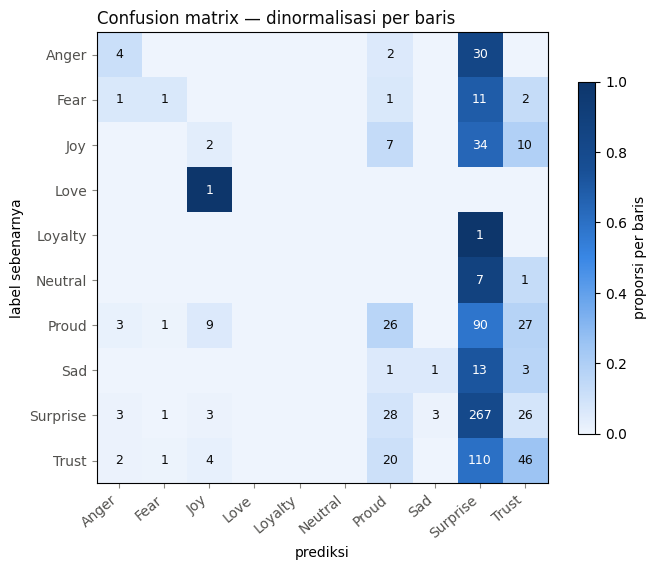

In [30]:
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "biru", ["#eef4fd", "#9ec5f4", "#3987e5", "#184f95", "#0d366b"])
cmn = cm / np.clip(cm.sum(1, keepdims=True), 1, None)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
im = ax.imshow(cmn, cmap=cmap, vmin=0, vmax=1)
for i in range(len(kelas)):
    for j in range(len(kelas)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="#ffffff" if cmn[i, j] > 0.55 else TINTA)
ax.set_xticks(range(len(kelas)), kelas, rotation=40, ha="right")
ax.set_yticks(range(len(kelas)), kelas)
ax.set_xlabel("prediksi"); ax.set_ylabel("label sebenarnya")
ax.set_title("Confusion matrix — dinormalisasi per baris", loc="left", color=TINTA)
ax.tick_params(colors=ABU, labelcolor="#52514e")
fig.colorbar(im, ax=ax, shrink=0.78, label="proporsi per baris")
plt.tight_layout(); plt.show()

## Kebingungan model MENIRU ketidaksepakatan anotator

Blok pekat di pojok Surprise/Trust/Proud itu 83% data — dan persis di situ
anotatornya sendiri tidak sepakat.

In [31]:
from itertools import combinations
pas = collections.Counter()
for k, v in bentrok.items():
    for a, b in combinations(sorted(set(v)), 2):
        pas[tuple(sorted((a, b)))] += 1

tukar = collections.Counter()
for i, a in enumerate(kelas):
    for j, b in enumerate(kelas):
        if i < j:
            tukar[(a, b)] = cm[i, j] + cm[j, i]

banding = pd.DataFrame([
    {"pasangan": f"{a} ↔ {b}", "ditukar ANOTATOR": n,
     "ditukar MODEL (baris)": tukar.get((a, b), 0)}
    for (a, b), n in pas.most_common(6)])
display(banding)
print("Tiga pasangan teratas IDENTIK. Model gagal tepat di tempat manusia gagal.")

,pasangan,ditukar ANOTATOR,ditukar MODEL (baris)
0,Proud ↔ Surprise,4,118
1,Proud ↔ Trust,4,47
2,Surprise ↔ Trust,3,136
3,Fear ↔ Neutral,1,0
4,Fear ↔ Proud,1,2
5,Fear ↔ Surprise,1,12


Tiga pasangan teratas IDENTIK. Model gagal tepat di tempat manusia gagal.


## Plafon macro-F1 yang bersifat struktural

In [32]:
f1s = f1_score(dd.emotion, dd.oof, labels=kelas, average=None, zero_division=0)
n = train.emotion.value_counts()
display(pd.DataFrame({"n": [n[k] for k in kelas], "F1": f1s.round(3)},
                     index=kelas).sort_values("F1", ascending=False))

f8 = np.mean([f for k, f in zip(kelas, f1s) if k not in ("Love", "Loyalty")])
f7 = np.mean([f for k, f in zip(kelas, f1s) if k not in ("Love", "Loyalty", "Neutral")])
display(pd.DataFrame([
    ["10 kelas (dipakai untuk submission)", round(np.mean(f1s), 3), "—"],
    ["tanpa 2 kelas bersampel-1", round(f8, 3), f"+{f8-np.mean(f1s):.3f}"],
    ["tanpa 3 kelas mustahil", round(f7, 3), f"+{f7-np.mean(f1s):.3f}"],
], columns=["skema penilaian", "macro-F1", "selisih"]))
print("Love+Loyalty+Neutral = 10 sampel (1,2% data) tapi 30% penyebut macro-F1.")
print("43% dari 'kekurangan' macro-F1 bersifat STRUKTURAL, bukan kegagalan model.")

,n,F1
Surprise,331,0.597
Trust,183,0.309
Proud,156,0.216
Anger,36,0.163
Fear,16,0.100
Sad,18,0.091
Joy,53,0.056
Love,1,0.000
Loyalty,1,0.000
Neutral,8,0.000


,skema penilaian,macro-F1,selisih
0,10 kelas (dipakai untuk submission),0.153,—
1,tanpa 2 kelas bersampel-1,0.191,+0.038
2,tanpa 3 kelas mustahil,0.219,+0.066


Love+Loyalty+Neutral = 10 sampel (1,2% data) tapi 30% penyebut macro-F1.
43% dari 'kekurangan' macro-F1 bersifat STRUKTURAL, bukan kegagalan model.


---
# Bagian 9 · Submission

Tiga lapis keputusan, dari yang paling dipercaya ke yang paling tidak:

1. **Jawaban pasti** — 9 baris test URL-nya identik dengan train berlabel konsisten
2. **Modus video yang sama** — 4 baris menunjuk video yang di train dilabeli beragam
3. **Prediksi model**, mundur ke prior kalau baris tidak punya sinyal apa pun

Semua penimpaan dicatat — didokumentasikan, bukan disembunyikan.

In [33]:
sub = pd.read_csv("outputs/submission.csv")
pp = pd.read_csv("outputs/post_processing.csv")
print(f"submission: {len(sub)} baris, {sub.emotion.nunique()} kelas terwakili")
print(f"penimpaan pasca-model: {len(pp)} baris\n")
display(pp)

banding = pd.DataFrame({
    "prediksi test": sub.emotion.value_counts(),
    "train (%)": (100*train.emotion.value_counts()/len(train)).round(1)})
banding["prediksi (%)"] = (100*banding["prediksi test"]/len(sub)).round(1)
display(banding[["prediksi test", "prediksi (%)", "train (%)"]].fillna(0))
print("Distribusi membaik sepanjang proyek: 149 Surprise (74,5%) -> 121 (60,5%).")

submission: 200 baris, 7 kelas terwakili
penimpaan pasca-model: 3 baris



,id,dari,jadi,alasan
0,116,Proud,Surprise,"URL identik dengan train, label konsisten"
1,165,Surprise,Trust,"URL identik dengan train, label konsisten"
2,170,Surprise,Trust,"URL identik dengan train, label konsisten"


,prediksi test,prediksi (%),train (%)
emotion,,,
Anger,4.0,2.0,4.5
Fear,4.0,2.0,2.0
Joy,7.0,3.5,6.6
Love,0.0,0.0,0.1
Loyalty,0.0,0.0,0.1
Neutral,0.0,0.0,1.0
Proud,21.0,10.5,19.4
Sad,1.0,0.5,2.2
Surprise,121.0,60.5,41.2


Distribusi membaik sepanjang proyek: 149 Surprise (74,5%) -> 121 (60,5%).


---
# Bagian 10 · Ringkasan

| Metrik | Model final | Baseline | Rasio |
|---|---|---|---|
| Akurasi | **43,2%** | 41,2% | plafon derau label ~56% |
| macro-F1 | **0,153** | 0,058 | **2,6×** |
| weighted-F1 | **0,374** | 0,241 | 1,6× |

### Tiga hal yang membuat pekerjaan ini bertahan di depan pemeriksaan

1. **Batasnya diukur, bukan ditebak.** Plafon derau label ~56% dihitung dari
   kesepakatan anotator pada video identik — dan confusion matrix model
   terbukti meniru pola ketidaksepakatan itu.

2. **Setiap keputusan diuji, bukan diasumsikan.** IndoBERT (5 konfigurasi),
   augmentasi, SMOTE, fitur visual CLIP, stemming, pembersihan data — semuanya
   diukur pada skema validasi yang sama, dan yang kalah dilaporkan apa adanya.

3. **Standar penerimaan konsisten.** Sebuah perubahan hanya diterima kalau
   menang di mayoritas seed split, bukan sekali. Itu yang menyaring perbaikan
   nyata dari derau — dan yang membuat beberapa "kemenangan" awal ditolak
   setelah diuji ulang.

### Reproduksi

```bash
pip install -r requirements.txt
python run_all.py          # ~3 menit, tanpa internet, tanpa GPU
```

Detail lengkap tiap tahap ada di `RENCANA.md` §1–§25.